# 🛒 Chương 3 — Dataset 3: Amazon Reviews — Stacked LSTM
## Kỹ thuật: Stacked LSTM + Multi-class Sentiment Classification

**Pipeline:** EDA → Rating Distribution → Preprocessing → Stacked LSTM → Train → Evaluate

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import re, os, glob, warnings

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

DATA_DIR = '../data/amazon_reviews'
SAVE_DIR = '../results/amazon_stacked_lstm'
os.makedirs(SAVE_DIR, exist_ok=True)

VOCAB_SIZE  = 20000
MAX_LEN     = 150
EMBED_DIM   = 128
EPOCHS      = 10
BATCH_SIZE  = 128
MAX_SAMPLES = 50000  # Limit for speed

print(f'TF: {tf.__version__}')

2026-05-09 20:11:04.841960: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 20:11:04.872282: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 20:11:05.445228: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TF: 2.13.0


## 📂 1. Load Amazon Reviews

In [ ]:
csv_files = glob.glob(f'{DATA_DIR}/**/*.csv', recursive=True) + glob.glob(f'{DATA_DIR}/*.csv')
print('Found:', csv_files)
df = pd.read_csv(csv_files[0])
if len(df) > MAX_SAMPLES:
    df = df.sample(MAX_SAMPLES, random_state=SEED).reset_index(drop=True)
    print(f'Sampled to {MAX_SAMPLES:,} rows')
print(f'Shape: {df.shape}')
df.head(3)

Found: ['../data/amazon_reviews/amazon_reviews.csv', '../data/amazon_reviews/amazon_reviews.csv']
Shape: (30000, 3)


,reviewText,overall,sentiment
0,Great product! Really happy with this purchase...,4,positive
1,Average product. Does what it's supposed to do...,3,neutral
2,"Excellent quality, fast shipping. Would defini...",5,positive


In [3]:
# Identify columns
text_col  = [c for c in df.columns if any(k in c.lower() for k in ['review','text','comment','summary','body'])][0]
label_col = [c for c in df.columns if any(k in c.lower() for k in ['sentiment','label','rating','score','class'])][0]
print(f'Text: {text_col}, Label: {label_col}')

df = df[[text_col, label_col]].dropna()
df.columns = ['text', 'label']
print(df['label'].value_counts())

Text: reviewText, Label: sentiment
label
positive    19454
negative     6023
neutral      4523
Name: count, dtype: int64


In [4]:
# Map to 3-class sentiment
if df['label'].dtype == object:
    pos_keys = ['positive','pos','5','4','good']
    neg_keys = ['negative','neg','1','2','bad']
    def map_label(x):
        x = str(x).lower().strip()
        if any(k in x for k in pos_keys): return 2
        if any(k in x for k in neg_keys): return 0
        return 1
    df['label'] = df['label'].apply(map_label)
elif df['label'].max() == 5:
    # Rating 1-2 → Negative, 3 → Neutral, 4-5 → Positive
    df['label'] = df['label'].apply(lambda r: 0 if r<=2 else (1 if r==3 else 2))
elif df['label'].max() == 1:
    pass  # already binary

NUM_CLASSES = df['label'].nunique()
print(f'\n3-Class distribution:\n{df["label"].value_counts().sort_index()}')
print(f'Num classes: {NUM_CLASSES}')


3-Class distribution:
label
0     6023
1     4523
2    19454
Name: count, dtype: int64
Num classes: 3


## 📊 2. EDA

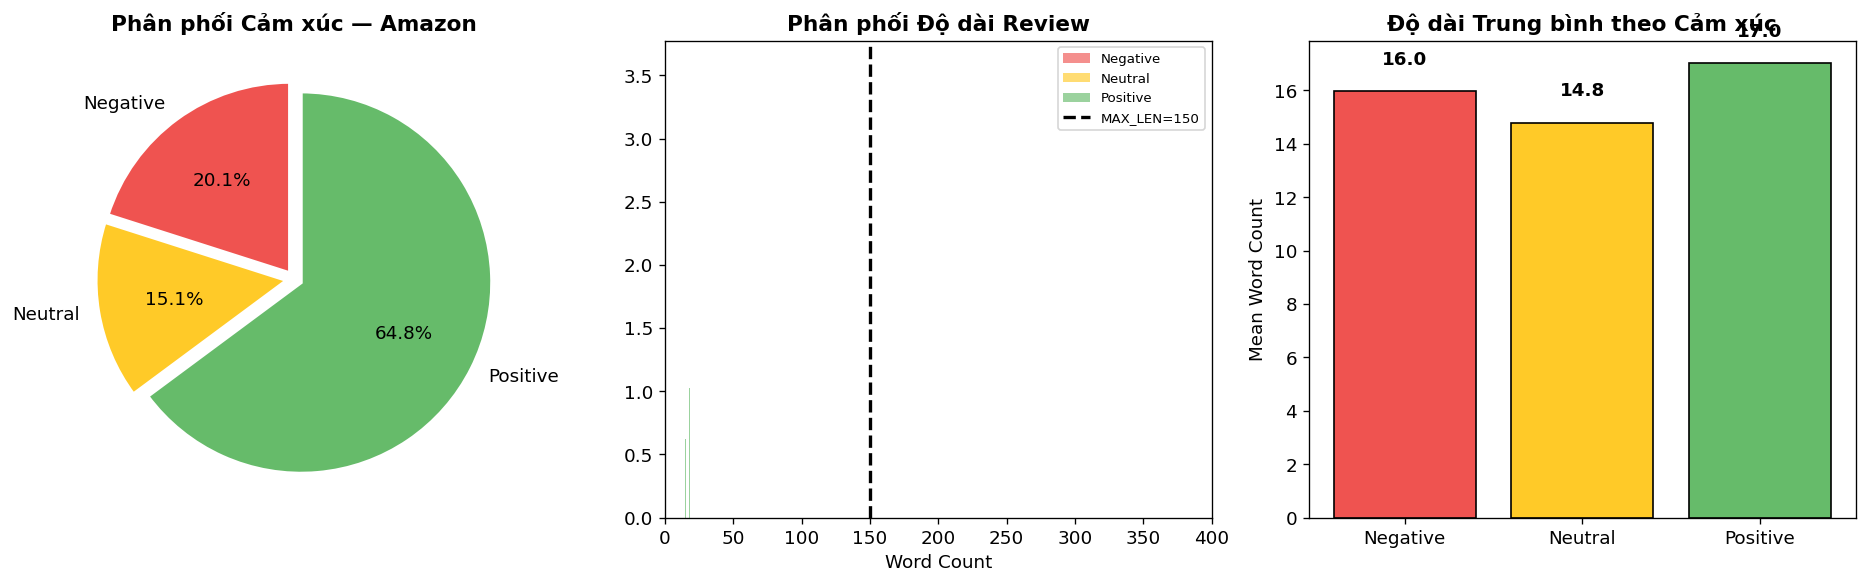

In [5]:
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
label_names = {0:'Negative', 1:'Neutral', 2:'Positive'}
colors = ['#EF5350', '#FFCA28', '#66BB6A']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart
counts = df['label'].value_counts().sort_index()
axes[0].pie(counts.values,
            labels=[label_names.get(i, str(i)) for i in counts.index],
            autopct='%1.1f%%', colors=colors[:NUM_CLASSES],
            explode=[0.04]*NUM_CLASSES, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Phân phối Cảm xúc — Amazon')

# Text length per class
for lbl, color in zip(sorted(df['label'].unique()), colors):
    axes[1].hist(df[df['label']==lbl]['text_len'], bins=40,
                 alpha=0.65, color=color,
                 label=label_names.get(lbl, str(lbl)), density=True)
axes[1].axvline(MAX_LEN, color='black', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Phân phối Độ dài Review')
axes[1].set_xlabel('Word Count')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 400)

# Mean review length per sentiment
mean_lens = df.groupby('label')['text_len'].mean()
bar_labels = [label_names.get(i, str(i)) for i in mean_lens.index]
axes[2].bar(bar_labels, mean_lens.values, color=colors[:NUM_CLASSES], edgecolor='black')
axes[2].set_title('Độ dài Trung bình theo Cảm xúc')
axes[2].set_ylabel('Mean Word Count')
for i, v in enumerate(mean_lens.values):
    axes[2].text(i, v+1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_eda_overview.png', bbox_inches='tight')
plt.show()

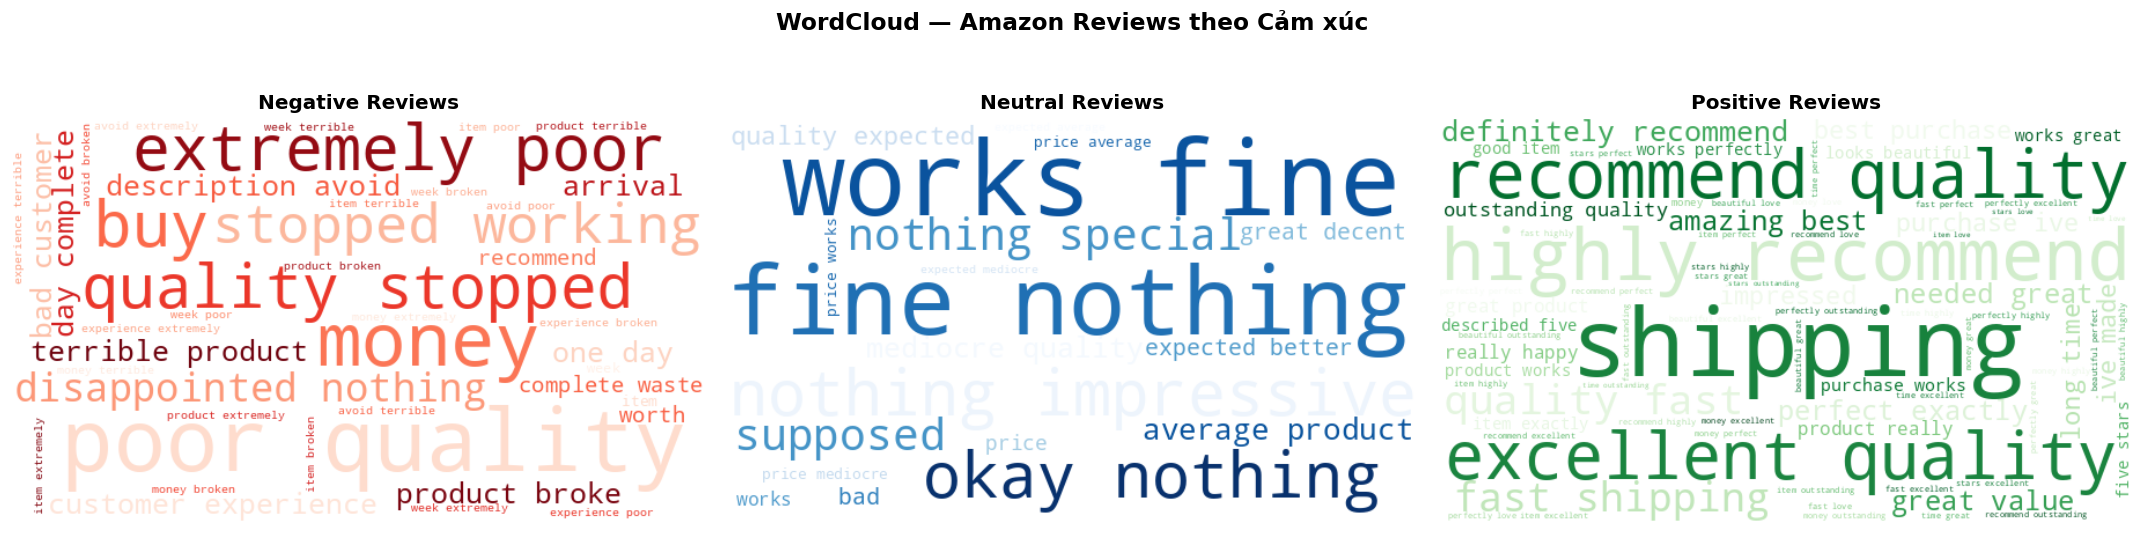

In [6]:
# WordClouds
def clean_text(text):
    return re.sub(r'[^a-z\s]', '', str(text).lower())

unique_labels = sorted(df['label'].unique())
cmaps = ['Reds', 'Blues', 'Greens']

fig, axes = plt.subplots(1, len(unique_labels), figsize=(6*len(unique_labels), 5))
if len(unique_labels) == 1:
    axes = [axes]

for ax, lbl, cmap in zip(axes, unique_labels, cmaps):
    corpus = ' '.join(df[df['label']==lbl]['text'].apply(clean_text).tolist())
    wc = WordCloud(width=600, height=350, max_words=100,
                   colormap=cmap, background_color='white').generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label_names.get(lbl, str(lbl))} Reviews', fontsize=12)

plt.suptitle('WordCloud — Amazon Reviews theo Cảm xúc', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_wordclouds.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing

In [ ]:
df['clean'] = df['text'].apply(clean_text)
X = df['clean'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Train: {X_train_pad.shape}, Test: {X_test_pad.shape}')

Train: (24000, 150), Test: (6000, 150)


## 🏗️ 4. Stacked LSTM Model

In [8]:
loss_fn    = 'sparse_categorical_crossentropy'
out_units  = NUM_CLASSES
activation = 'softmax'

model = models.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, name='embedding'),
    layers.SpatialDropout1D(0.2),
    # Stacked LSTM layers
    layers.LSTM(128, return_sequences=True, name='lstm_1'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.LSTM(64, return_sequences=True, name='lstm_2'),
    layers.Dropout(0.3),
    layers.LSTM(32, name='lstm_3'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(out_units, activation=activation, name='output')
], name='StackedLSTM_Amazon')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=loss_fn,
              metrics=['accuracy'])
model.summary()

2026-05-09 20:11:08.187024: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 20:11:08.189340: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 20:11:08.190896: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "StackedLSTM_Amazon"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 150, 128)          2560000   
                                                                 
 spatial_dropout1d (Spatial  (None, 150, 128)          0         
 Dropout1D)                                                      
                                                                 
 lstm_1 (LSTM)               (None, 150, 128)          131584    
                                                                 
 batch_normalization (Batch  (None, 150, 128)          512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 150, 128)          0         
                                                                 
 lstm_2 (LSTM)               (None, 150, 64)    

## 🚀 5. Training

In [9]:
history = model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)

Epoch 1/10
160/160 [==============================] - 29s 166ms/step - loss: 0.9033 - accuracy: 0.6410 - val_loss: 0.8803 - val_accuracy: 0.6544 - lr: 0.0010
Epoch 2/10
160/160 [==============================] - 26s 160ms/step - loss: 0.8947 - accuracy: 0.6474 - val_loss: 0.8858 - val_accuracy: 0.6544 - lr: 0.0010
Epoch 3/10
160/160 [==============================] - ETA: 0s - loss: 0.8928 - accuracy: 0.6474
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
160/160 [==============================] - 26s 163ms/step - loss: 0.8928 - accuracy: 0.6474 - val_loss: 0.8815 - val_accuracy: 0.6544 - lr: 0.0010
Epoch 4/10
160/160 [==============================] - 25s 159ms/step - loss: 0.8920 - accuracy: 0.6474 - val_loss: 0.8863 - val_accuracy: 0.6544 - lr: 5.0000e-04


## 📈 6. Evaluation

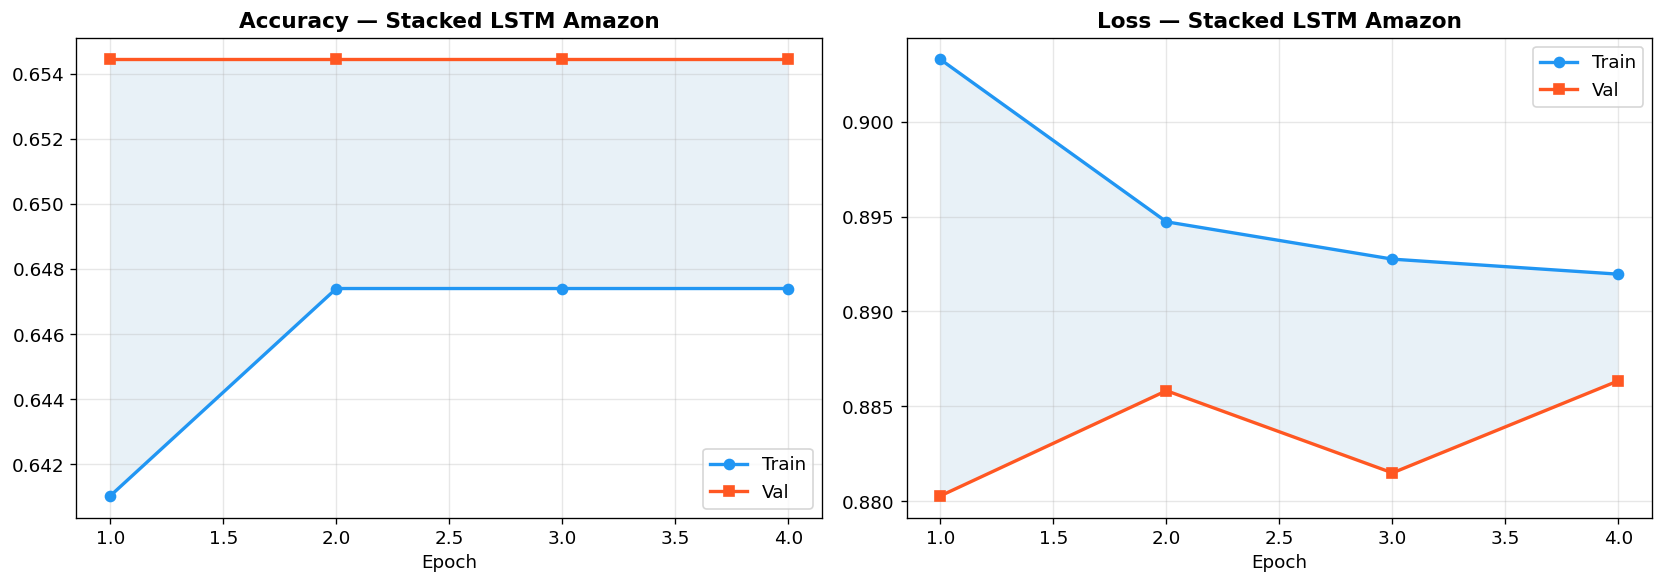

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history.history['accuracy'])+1)
for ax, (tr, vl, metric) in zip(axes, [
    ('accuracy','val_accuracy','Accuracy'),
    ('loss','val_loss','Loss')
]):
    ax.plot(eps, history.history[tr], 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(eps, history.history[vl], 's-', color='#FF5722', lw=2, label='Val')
    ax.fill_between(eps, history.history[tr], history.history[vl], alpha=0.1)
    ax.set_title(f'{metric} — Stacked LSTM Amazon')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_training_history.png', bbox_inches='tight')
plt.show()

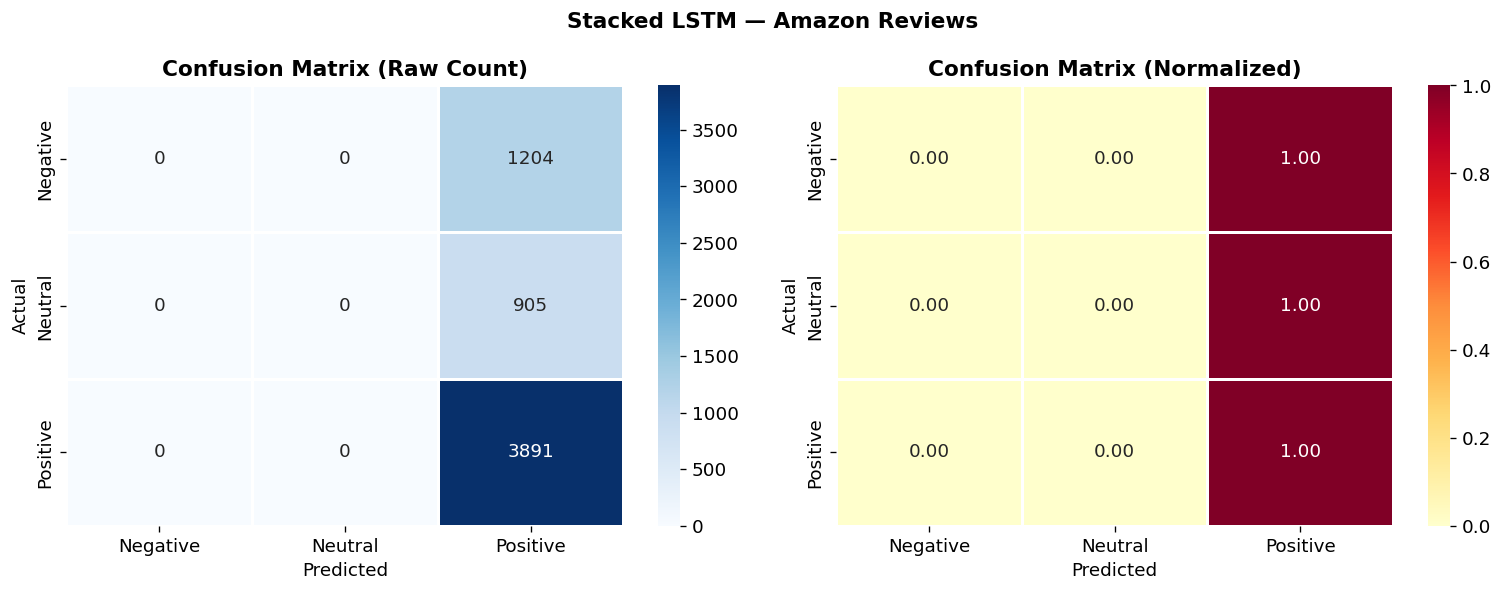

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      1204
     Neutral       0.00      0.00      0.00       905
    Positive       0.65      1.00      0.79      3891

    accuracy                           0.65      6000
   macro avg       0.22      0.33      0.26      6000
weighted avg       0.42      0.65      0.51      6000



In [11]:
y_pred_prob = model.predict(X_test_pad, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
target_names_list = [label_names.get(i, str(i)) for i in sorted(df['label'].unique())]

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_list,
            yticklabels=target_names_list,
            linewidths=0.8, ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Count)')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=target_names_list,
            yticklabels=target_names_list,
            linewidths=0.8, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.suptitle('Stacked LSTM — Amazon Reviews', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=target_names_list))

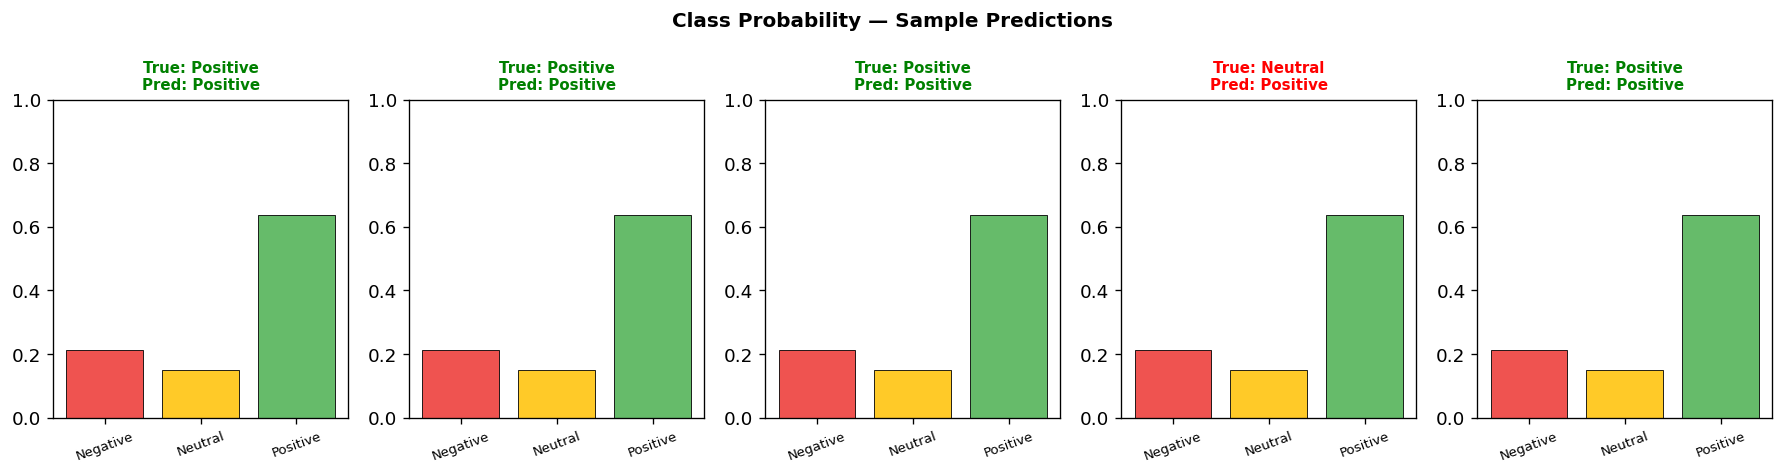

In [12]:
# Class probability visualization for sample predictions
sample_indices = [0, 1, 2, 3, 4]
fig, axes = plt.subplots(1, len(sample_indices), figsize=(15, 4))

for ax, idx in zip(axes, sample_indices):
    probs = y_pred_prob[idx]
    bars  = ax.bar(target_names_list, probs,
                   color=['#EF5350','#FFCA28','#66BB6A'][:NUM_CLASSES],
                   edgecolor='black', linewidth=0.5)
    pred_lbl = target_names_list[np.argmax(probs)]
    true_lbl = target_names_list[y_test[idx]]
    color = 'green' if pred_lbl==true_lbl else 'red'
    ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl}', color=color, fontsize=9)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20, labelsize=8)

plt.suptitle('Class Probability — Sample Predictions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_sample_predictions.png', bbox_inches='tight')
plt.show()

In [13]:
best_acc = max(history.history['val_accuracy'])
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Amazon Reviews — Stacked LSTM\n' + '='*50 + '\n')
    f.write(f'Best Val Accuracy: {best_acc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write(classification_report(y_test, y_pred, target_names=target_names_list))

print('✅ Amazon Stacked LSTM Done! Saved to', SAVE_DIR)

✅ Amazon Stacked LSTM Done! Saved to ../results/amazon_stacked_lstm
